In [2]:
#Importation des dep
import os
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
print("Importation reussi")

Importation reussi


In [3]:
#chargement des données 
DATASET_PATH = Path("/home/rolls/M1/IA/DataScience/Projets/Detection_Deforestation_IA/data/raw")
FOREST_PATH = DATASET_PATH/ "forest"
NON_FOREST_PATH = DATASET_PATH/ "non_forest"
print("chemin :", DATASET_PATH.exists())
print("forest :", FOREST_PATH.exists())
print("non forest :", NON_FOREST_PATH.exists())

chemin : True
forest : True
non forest : True


In [4]:
#Extension des images accepter
IMAGE_EXTENSION = {".jpeg", ".jpg", ".png", ".tif", ".tiff"}
def compter_image(dossier):
    "compter le nombre des image dans un dossier et sous_dossier"
    return sum(
        1
        for fichier in dossier.rglob("*")
        if fichier.is_file() and fichier.suffix.lower() in IMAGE_EXTENSION
    )
#compter les data:
nbr_foret = compter_image(FOREST_PATH)
nbr_non_foret = compter_image(NON_FOREST_PATH)
nb_total = nbr_foret + nbr_non_foret
print(f" Forest      : {nbr_foret}")
print(f" Non-Forest  : {nbr_non_foret}")
print(f" Total       : {nb_total}")


 Forest      : 4000
 Non-Forest  : 4000
 Total       : 8000


In [5]:
from collections import Counter
#gerer les fomats des image pour voir si c'est sont tous des images
def counter_format(dossier):
    #compter les differ formats des images dans les dossiers
    formats = Counter()
    for fichier in dossier.rglob("*"):
        if fichier.is_file():
            formats[fichier.suffix.lower()] += 1
    return formats

formats_forest = counter_format(FOREST_PATH)
formats_non_forest = counter_format(NON_FOREST_PATH)
print("===FOREST===")
print(formats_forest)
print("\n=======non forest=====")
print(formats_non_forest)

===FOREST===
Counter({'.png': 4000})

=======non forest=====
Counter({'.png': 4000})


In [22]:
from PIL import Image
#Verifier le dimension des images
def compter_dimension(dossier):
    dimension = Counter()
    for fichier in dossier.rglob("*.png"):
        try:
            with Image.open(fichier) as img:
                dimension[img.size] += 1
        except Exeption:
            pass
    return dimension

dimension_forest = compter_dimension(FOREST_PATH)
dimension_non_forest = compter_dimension(NON_FOREST_PATH)
print("===forest===")
print(dimension_forest)
print("\n====non_forest====")
print(dimension_non_forest)
            

===forest===
Counter({(128, 128): 4000})

====non_forest====
Counter({(128, 128): 4000})


In [6]:
#verifier l'image corrompu
def verifier_image(dossier):
    img_corrompu = []
    for fichier in dossier.rglob("*.png"):
        try:
            with Image.open(fichier) as img:
                img.verify()
        except Except:
            img_corrompu.append(fichier)
    return img_corrompu

In [7]:
forest_corrompu = verifier_image(FOREST_PATH)
non_forest_corrompu = verifier_image(NON_FOREST_PATH)
print("forest corrompu :", len(forest_corrompu))
print("non forest corrompu :", len(non_forest_corrompu))

forest corrompu : 0
non forest corrompu : 0


In [8]:
import random 
#visualiser les images 
def afficher_image(dossier, titre, nbr = 5):
    """ afficher un nombre aleatoirement des image """
    images = list(dossier.rglob("*.png"))
    images_aleatoires = random.sample(images, nbr)
    plt.figure(figsize = (15, 3))

    for i, image_path in enumerate(images_aleatoires):
        img = Image.open(image_path)

        plt.subplot(1, nbr, i+1)    
        plt.imshow(img)
        plt.title(titre)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

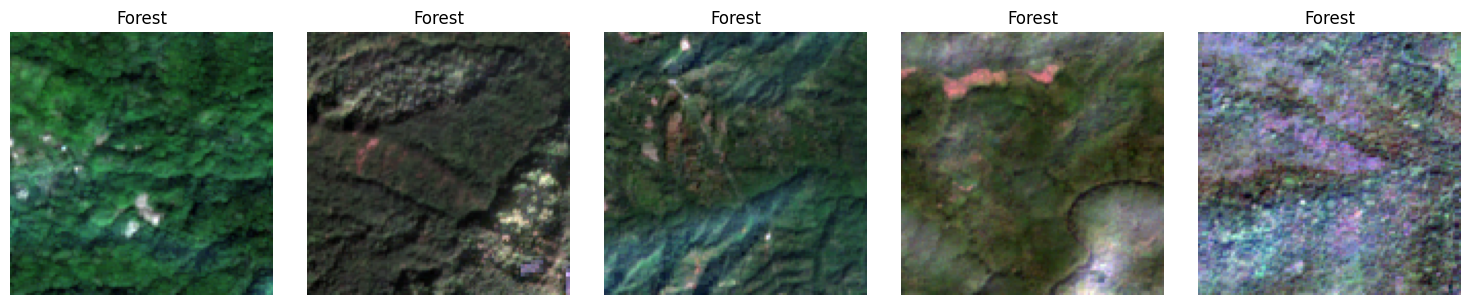

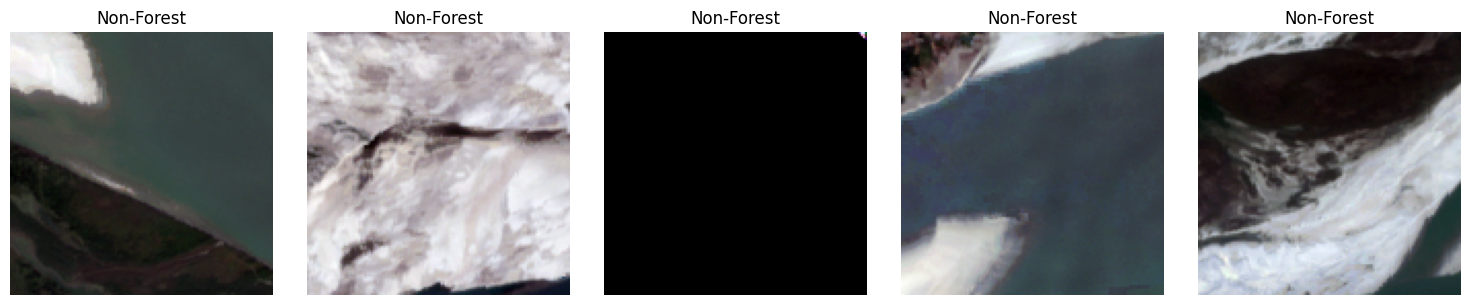

In [9]:
afficher_image(FOREST_PATH, "Forest")
afficher_image(NON_FOREST_PATH, "Non-Forest")